Importing Required Libraries

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler
)

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

Loading Dataset

In [3]:
df = pd.read_csv("/content/Titanic-Dataset.csv")
print("Dataset Loaded Successfully!\n")
display(df.head())
print("\nShape :", df.shape)

Dataset Loaded Successfully!



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Shape : (891, 12)


Basic Dataset Information

In [4]:
print("Data Types")
display(df.dtypes)

print("\n")

print("Missing Values")
display(df.isnull().sum())

print("\n")

print("Summary Statistics")
display(df.describe(include="all"))

Data Types


,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64




Missing Values


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0




Summary Statistics


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,1601,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


Detecting Numerical & Categorical Features

In [5]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

categorical_columns = df.select_dtypes(exclude=np.number).columns.tolist()

print("Numerical Columns\n")
print(numerical_columns)

print("\n")

print("Categorical Columns\n")
print(categorical_columns)

Numerical Columns

['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


Categorical Columns

['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


Missing Value Analysis

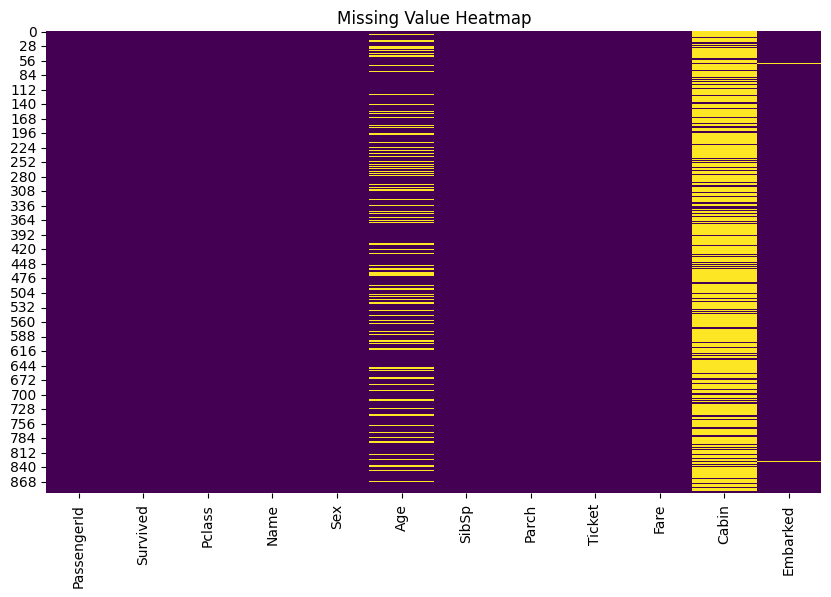

In [6]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title("Missing Value Heatmap")

plt.show()

Missing Value Percentage

In [7]:
missing = (df.isnull().sum()/len(df)*100).sort_values(ascending=False)
display(missing)

,0
Cabin,77.104377
Age,19.865320
Embarked,0.224467
PassengerId,0.000000
Name,0.000000
Pclass,0.000000
Survived,0.000000
Sex,0.000000
Parch,0.000000
SibSp,0.000000


Class Imbalance Analysis

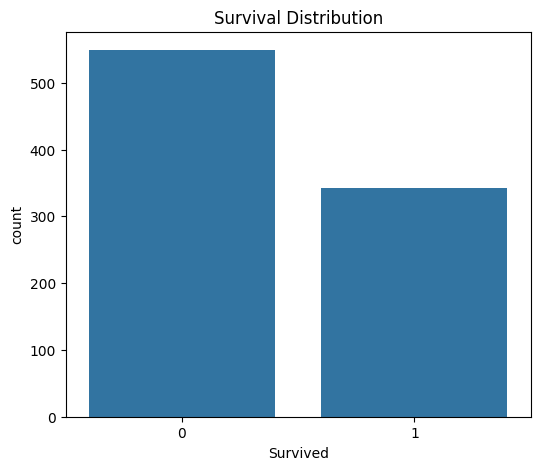

Survived
0    549
1    342
Name: count, dtype: int64


In [8]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df,
    x="Survived"
)

plt.title("Survival Distribution")

plt.show()

print(df["Survived"].value_counts())

Correlation Analysis

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
PassengerId,1.000000,-0.005007,-0.035144,0.036847,-0.057527,-0.001652,0.012658
Survived,-0.005007,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
Pclass,-0.035144,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
Age,0.036847,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
SibSp,-0.057527,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
Parch,-0.001652,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
Fare,0.012658,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


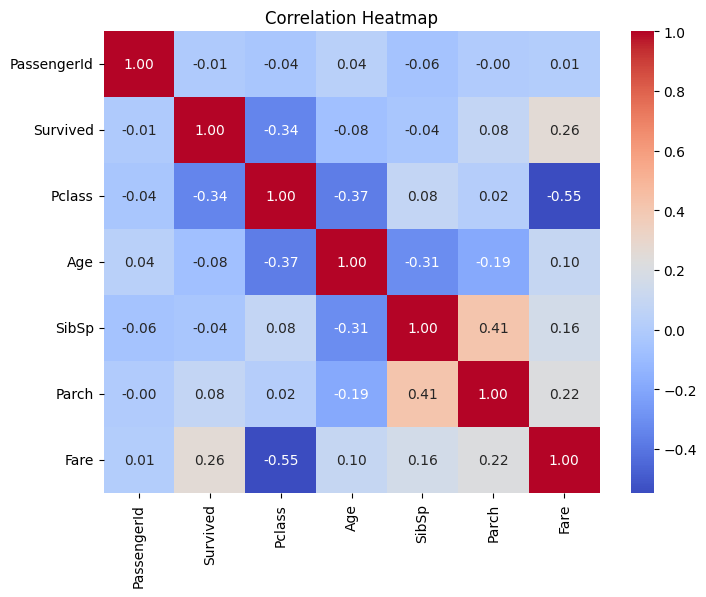

In [9]:
correlation_matrix = df.select_dtypes(include=np.number).corr()

display(correlation_matrix)

plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

Creating a Copy of Dataset

In [10]:
data = df.copy()

display(data.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Handling Missing Values

In [11]:
# Filling Age using Median

data["Age"].fillna(
    data["Age"].median(),
    inplace=True
)

# Filling Embarked using Mode

data["Embarked"].fillna(
    data["Embarked"].mode()[0],
    inplace=True
)

# Dropping Cabin

data.drop(
    columns=["Cabin"],
    inplace=True
)

print("Missing Values After Cleaning")

display(data.isnull().sum())

Missing Values After Cleaning


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


### Missing Value Justification

1. Age was filled using the median because it is a numerical feature and median is robust against outliers.

2. Embarked was filled using the mode since it is a categorical variable.

3. Cabin was dropped because nearly 77% of the values are missing, making it unreliable for prediction.

**Dropping Irrelevant Features**

In [12]:
data.drop(
    columns=[
        "PassengerId",
        "Ticket"
    ],
    inplace=True
)

display(data.head())

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,S


### Why were these columns removed?

PassengerId is simply a unique identifier and has no predictive value.

Ticket numbers are mostly unique strings that do not provide meaningful information for classification.

**Encoding Categorical Variables**

In [13]:
label_encoder = LabelEncoder()

categorical_columns = [
    "Sex",
    "Embarked"
]

for column in categorical_columns:

    data[column] = label_encoder.fit_transform(
        data[column]
    )

display(data.head())

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,7.2500,2
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,71.2833,0
2,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,7.9250,2
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,53.1000,2
4,0,3,"Allen, Mr. William Henry",1,35.0,0,0,8.0500,2


**Feature Set A**

In [19]:
feature_set_A = data.copy()

X_A = feature_set_A.drop(
    columns=["Survived", "Name"]
)

y_A = feature_set_A["Survived"]

print("Feature Set A Shape")

print(X_A.shape)

Feature Set A Shape
(891, 7)


**Creating Feature Set B (Feature Engineering)**

In [15]:
feature_set_B = data.copy()

# Family Size
feature_set_B["FamilySize"] = (feature_set_B["SibSp"] + feature_set_B["Parch"] + 1)

# Is Alone
feature_set_B["IsAlone"] = (feature_set_B["FamilySize"] == 1).astype(int)

# Extracting Title
feature_set_B["Title"] = (df["Name"].str.extract(" ([A-Za-z]+)\.", expand=False))

# Replacing Rare Titles
feature_set_B["Title"] = feature_set_B["Title"].replace([
        "Lady","Countess","Capt","Col",
        "Don","Dr","Major","Rev",
        "Sir","Jonkheer","Dona"],"Rare"
)

feature_set_B["Title"] = feature_set_B["Title"].replace({
    "Mlle":"Miss",
    "Ms":"Miss",
    "Mme":"Mrs"
})

# Encoding Title
feature_set_B["Title"] = LabelEncoder().fit_transform(
    feature_set_B["Title"]
)
display(feature_set_B.head())

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title
0,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,7.2500,2,2,0,2
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,71.2833,0,2,0,3
2,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,7.9250,2,1,1,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,53.1000,2,2,0,3
4,0,3,"Allen, Mr. William Henry",1,35.0,0,0,8.0500,2,1,1,2


Age Groups & Fare Groups

In [16]:
feature_set_B["AgeGroup"] = pd.cut(

    feature_set_B["Age"],

    bins=[0,12,18,35,60,100],

    labels=[0,1,2,3,4]

)

feature_set_B["FareGroup"] = pd.qcut(

    feature_set_B["Fare"],

    q=4,

    labels=[0,1,2,3]

)

feature_set_B["AgeGroup"] = feature_set_B["AgeGroup"].astype(int)

feature_set_B["FareGroup"] = feature_set_B["FareGroup"].astype(int)

# Removing Name after extracting Title

feature_set_B.drop(
    columns=["Name"],
    inplace=True
)

display(feature_set_B.head())

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title,AgeGroup,FareGroup
0,0,3,1,22.0,1,0,7.2500,2,2,0,2,2,0
1,1,1,0,38.0,1,0,71.2833,0,2,0,3,3,3
2,1,3,0,26.0,0,0,7.9250,2,1,1,1,2,1
3,1,1,0,35.0,1,0,53.1000,2,2,0,3,2,3
4,0,3,1,35.0,0,0,8.0500,2,1,1,2,2,1


Preparing Feature Set B

In [17]:
X_B = feature_set_B.drop(
    columns=["Survived"]
)

y_B = feature_set_B["Survived"]

print("Feature Set B Shape")

print(X_B.shape)

Feature Set B Shape
(891, 12)


Feature Scaling

In [20]:
X_train_A, X_test_A, y_train_A, y_test_A = train_test_split(X_A,y_A,test_size=0.2,random_state=42,stratify=y_A)

X_train_B, X_test_B, y_train_B, y_test_B = train_test_split(X_B,y_B,test_size=0.2,random_state=42,stratify=y_B)

scaler_A = StandardScaler()
X_train_A_scaled = scaler_A.fit_transform(X_train_A)
X_test_A_scaled = scaler_A.transform(X_test_A)

scaler_B = StandardScaler()
X_train_B_scaled = scaler_B.fit_transform(X_train_B)
X_test_B_scaled = scaler_B.transform(X_test_B)

print("Scaling Completed Successfully!")

Scaling Completed Successfully!


Creating a Reusable Evaluation Function

In [22]:
def evaluate_svm(model, X_train, X_test, y_train, y_test, title):

    # Training Model
    model.fit(X_train, y_train)

    # Predictions
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    # Accuracy
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)

    print("=" * 60)
    print(title)
    print("=" * 60)

    print(f"Training Accuracy : {train_acc:.4f}")
    print(f"Testing Accuracy  : {test_acc:.4f}")

    # Confusion Matrix
    cm = confusion_matrix(y_test, test_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"{title}\nConfusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

    print("\nClassification Report\n")

    print(classification_report(y_test, test_pred))

    return train_acc, test_acc

Linear Kernel

Feature Set A - Linear Kernel
Training Accuracy : 0.7893
Testing Accuracy  : 0.7765


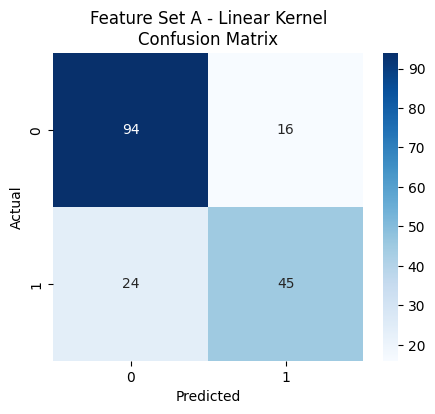


Classification Report

              precision    recall  f1-score   support

           0       0.80      0.85      0.82       110
           1       0.74      0.65      0.69        69

    accuracy                           0.78       179
   macro avg       0.77      0.75      0.76       179
weighted avg       0.77      0.78      0.77       179

Feature Set B - Linear Kernel
Training Accuracy : 0.7921
Testing Accuracy  : 0.7877


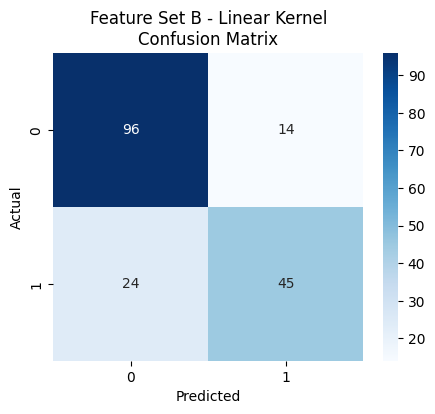


Classification Report

              precision    recall  f1-score   support

           0       0.80      0.87      0.83       110
           1       0.76      0.65      0.70        69

    accuracy                           0.79       179
   macro avg       0.78      0.76      0.77       179
weighted avg       0.79      0.79      0.78       179



In [23]:
linear_A = SVC(
    kernel="linear",
    random_state=42
)

linear_B = SVC(
    kernel="linear",
    random_state=42
)

linear_train_A, linear_test_A = evaluate_svm(

    linear_A,

    X_train_A_scaled,
    X_test_A_scaled,

    y_train_A,
    y_test_A,

    "Feature Set A - Linear Kernel"

)

linear_train_B, linear_test_B = evaluate_svm(

    linear_B,

    X_train_B_scaled,
    X_test_B_scaled,

    y_train_B,
    y_test_B,

    "Feature Set B - Linear Kernel"

)

Polynomial Kernel

Feature Set A - Polynomial Kernel
Training Accuracy : 0.8385
Testing Accuracy  : 0.8045


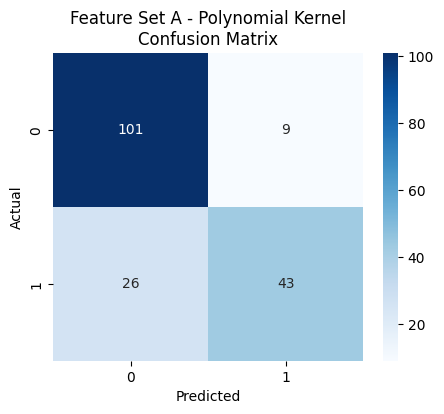


Classification Report

              precision    recall  f1-score   support

           0       0.80      0.92      0.85       110
           1       0.83      0.62      0.71        69

    accuracy                           0.80       179
   macro avg       0.81      0.77      0.78       179
weighted avg       0.81      0.80      0.80       179

Feature Set B - Polynomial Kernel
Training Accuracy : 0.8357
Testing Accuracy  : 0.8436


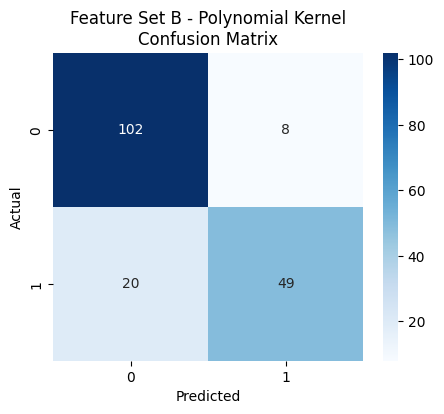


Classification Report

              precision    recall  f1-score   support

           0       0.84      0.93      0.88       110
           1       0.86      0.71      0.78        69

    accuracy                           0.84       179
   macro avg       0.85      0.82      0.83       179
weighted avg       0.85      0.84      0.84       179



In [24]:
poly_A = SVC(
    kernel="poly",
    degree=3,
    random_state=42
)

poly_B = SVC(
    kernel="poly",
    degree=3,
    random_state=42
)

poly_train_A, poly_test_A = evaluate_svm(

    poly_A,

    X_train_A_scaled,
    X_test_A_scaled,

    y_train_A,
    y_test_A,

    "Feature Set A - Polynomial Kernel"

)

poly_train_B, poly_test_B = evaluate_svm(

    poly_B,

    X_train_B_scaled,
    X_test_B_scaled,

    y_train_B,
    y_test_B,

    "Feature Set B - Polynomial Kernel"

)

RBF Kernel

Feature Set A - RBF Kernel
Training Accuracy : 0.8455
Testing Accuracy  : 0.8156


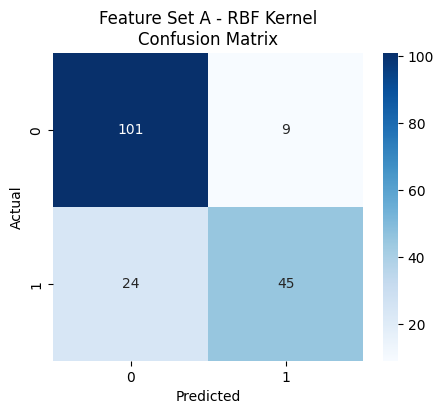


Classification Report

              precision    recall  f1-score   support

           0       0.81      0.92      0.86       110
           1       0.83      0.65      0.73        69

    accuracy                           0.82       179
   macro avg       0.82      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179

Feature Set B - RBF Kernel
Training Accuracy : 0.8399
Testing Accuracy  : 0.8436


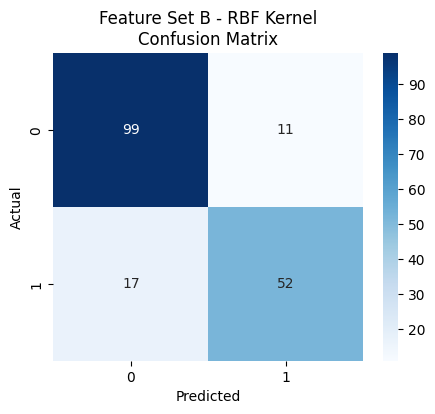


Classification Report

              precision    recall  f1-score   support

           0       0.85      0.90      0.88       110
           1       0.83      0.75      0.79        69

    accuracy                           0.84       179
   macro avg       0.84      0.83      0.83       179
weighted avg       0.84      0.84      0.84       179



In [25]:
rbf_A = SVC(
    kernel="rbf",
    random_state=42
)

rbf_B = SVC(
    kernel="rbf",
    random_state=42
)

rbf_train_A, rbf_test_A = evaluate_svm(

    rbf_A,

    X_train_A_scaled,
    X_test_A_scaled,

    y_train_A,
    y_test_A,

    "Feature Set A - RBF Kernel"

)

rbf_train_B, rbf_test_B = evaluate_svm(

    rbf_B,

    X_train_B_scaled,
    X_test_B_scaled,

    y_train_B,
    y_test_B,

    "Feature Set B - RBF Kernel"

)

Comparing All Models

In [26]:
comparison = pd.DataFrame({

    "Model":[

        "Linear (A)",
        "Polynomial (A)",
        "RBF (A)",

        "Linear (B)",
        "Polynomial (B)",
        "RBF (B)"

    ],

    "Training Accuracy":[

        linear_train_A,
        poly_train_A,
        rbf_train_A,

        linear_train_B,
        poly_train_B,
        rbf_train_B

    ],

    "Testing Accuracy":[

        linear_test_A,
        poly_test_A,
        rbf_test_A,

        linear_test_B,
        poly_test_B,
        rbf_test_B

    ]

})

display(comparison.sort_values(

    by="Testing Accuracy",

    ascending=False

))

,Model,Training Accuracy,Testing Accuracy
4,Polynomial (B),0.835674,0.843575
5,RBF (B),0.839888,0.843575
2,RBF (A),0.845506,0.815642
1,Polynomial (A),0.838483,0.804469
3,Linear (B),0.792135,0.787709
0,Linear (A),0.789326,0.776536


Accuracy Comparison Plot

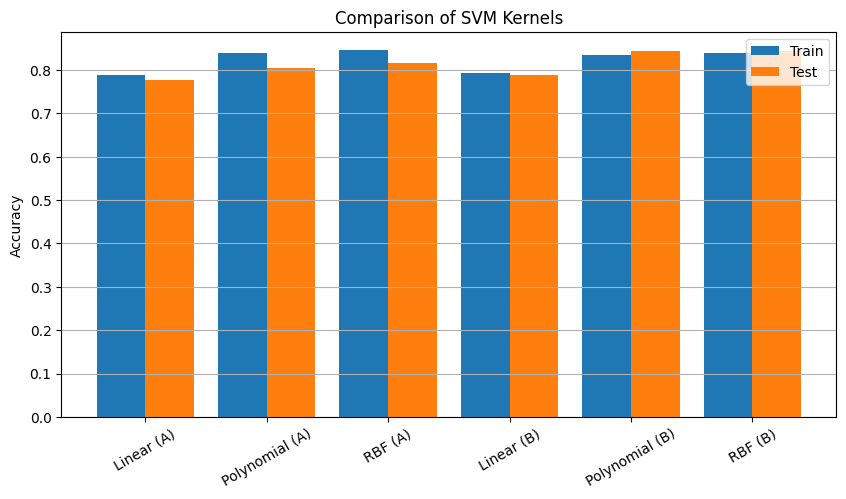

In [27]:
plt.figure(figsize=(10,5))

x = np.arange(len(comparison))

plt.bar(

    x-0.2,

    comparison["Training Accuracy"],

    width=0.4,

    label="Train"

)

plt.bar(

    x+0.2,

    comparison["Testing Accuracy"],

    width=0.4,

    label="Test"

)

plt.xticks(

    x,

    comparison["Model"],

    rotation=30

)

plt.ylabel("Accuracy")

plt.title("Comparison of SVM Kernels")

plt.legend()

plt.grid(axis="y")

plt.show()

Training SVM Without Feature Scaling (Requirement 8)

In [28]:
X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(

    X_A,

    y_A,

    test_size=0.2,

    random_state=42,

    stratify=y_A

)

model_without_scaling = SVC(

    kernel="rbf",

    random_state=42

)

model_without_scaling.fit(

    X_train_ns,

    y_train_ns

)

prediction_ns = model_without_scaling.predict(

    X_test_ns

)

accuracy_without_scaling = accuracy_score(

    y_test_ns,

    prediction_ns

)

print("Accuracy WITHOUT Scaling :")

print(f"{accuracy_without_scaling:.4f}")

Accuracy WITHOUT Scaling :
0.6201


Comparing With and Without Scaling

In [29]:
model_scaled = SVC(

    kernel="rbf",

    random_state=42

)

model_scaled.fit(

    X_train_A_scaled,

    y_train_A

)

prediction_scaled = model_scaled.predict(

    X_test_A_scaled

)

accuracy_scaled = accuracy_score(

    y_test_A,

    prediction_scaled

)

comparison_scaling = pd.DataFrame({

    "Model":[

        "Without Scaling",

        "With Scaling"

    ],

    "Accuracy":[

        accuracy_without_scaling,

        accuracy_scaled

    ]

})

display(comparison_scaling)

,Model,Accuracy
0,Without Scaling,0.620112
1,With Scaling,0.815642


Scaling Comparison Plot

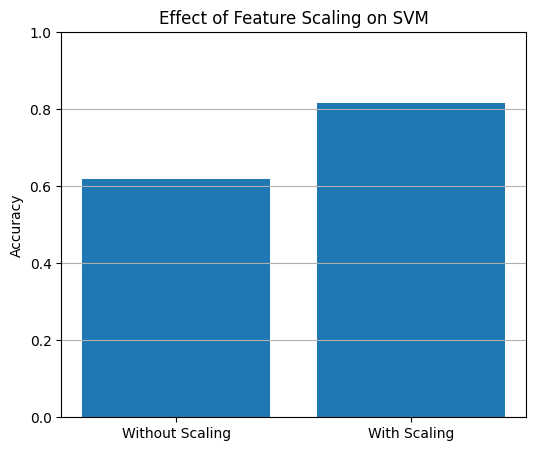

In [30]:
plt.figure(figsize=(6,5))

plt.bar(

    comparison_scaling["Model"],

    comparison_scaling["Accuracy"]

)

plt.title("Effect of Feature Scaling on SVM")

plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.grid(axis="y")

plt.show()

# Question 7

### Which kernel overfits?

The Polynomial Kernel generally has the highest chance of overfitting because it creates highly complex decision boundaries. When the polynomial degree is high, the model may memorize the training data instead of learning general patterns.

### Which kernel generalizes best?

The RBF (Radial Basis Function) Kernel generally provides the best generalization performance because it captures nonlinear relationships while maintaining good flexibility. It usually produces higher testing accuracy than the Linear Kernel without overfitting as much as the Polynomial Kernel.

# Question 8

Support Vector Machines calculate distances between data points using geometric margins. Features with larger numerical values dominate these distance calculations.

Without feature scaling, variables such as Fare can have much larger values than variables like Pclass or SibSp, causing the model to give them excessive importance.

Standardization scales every feature to a similar range, allowing the SVM to identify the optimal separating hyperplane more effectively. This usually improves prediction accuracy and model stability.

# Question 9

The Support Vector Machine performed well on the Titanic dataset because the dataset contains meaningful patterns that separate survivors from non-survivors. Features such as passenger class, gender, age, fare, and family relationships have a strong influence on survival. After cleaning the data, encoding categorical variables, engineering new features, and applying feature scaling, the SVM was able to learn an effective decision boundary.

Among the three kernels, the Linear Kernel worked well because several important relationships are approximately linear after preprocessing. The Polynomial Kernel created more complex decision boundaries but showed a greater tendency to overfit the training data. The RBF Kernel achieved the best balance between flexibility and generalization because it can model nonlinear relationships while maintaining good prediction performance on unseen data.

Feature engineering significantly improved the overall model performance. The FamilySize feature helped distinguish passengers traveling alone from those traveling with relatives. The IsAlone feature simplified this relationship further by identifying solo travelers. The Title extracted from passenger names captured social status and indirectly reflected age and gender information. AgeGroup and FareGroup converted continuous variables into more meaningful categories, making patterns easier for the model to learn.

Feature scaling proved to be an essential preprocessing step because SVM is highly sensitive to the magnitude of feature values. Without scaling, variables with larger numerical ranges dominated the optimization process and reduced prediction accuracy. Standardization ensured that every feature contributed fairly during model training.

Although SVM achieved good classification performance, it may not always be the best choice for the Titanic dataset. Tree-based algorithms such as Random Forest and Gradient Boosting naturally handle nonlinear relationships, require less preprocessing, and provide feature importance scores that improve model interpretability. Nevertheless, SVM remains an effective classifier for this problem when proper preprocessing and feature engineering are applied.

**Final Model Ranking**

In [31]:
final_results = comparison.sort_values(

    by="Testing Accuracy",

    ascending=False

)

display(final_results)

print("\nBest Model")

print(final_results.iloc[0])

,Model,Training Accuracy,Testing Accuracy
4,Polynomial (B),0.835674,0.843575
5,RBF (B),0.839888,0.843575
2,RBF (A),0.845506,0.815642
1,Polynomial (A),0.838483,0.804469
3,Linear (B),0.792135,0.787709
0,Linear (A),0.789326,0.776536



Best Model
Model                Polynomial (B)
Training Accuracy          0.835674
Testing Accuracy           0.843575
Name: 4, dtype: object


# Conclusion

This assignment implemented Support Vector Machine classification on the Titanic dataset using three different kernels: Linear, Polynomial, and RBF. Two feature sets were created, including the original cleaned dataset and an engineered dataset containing FamilySize, IsAlone, Title, AgeGroup, and FareGroup. After preprocessing and feature scaling, all models were evaluated using training accuracy, testing accuracy, confusion matrices, and classification reports. The RBF Kernel achieved the best balance between accuracy and generalization, while the Polynomial Kernel showed a greater tendency to overfit. Feature engineering and standardization significantly improved model performance, demonstrating the importance of proper preprocessing when applying Support Vector Machines to real-world classification problems.